Solution blew up for h = 0.1 at t = 0.6000000000000001
Solution blew up for h = 0.01 at t = 0.11
h = 1e-05 is computationally impractical (2,999,999 steps)
h = 1e-07 is computationally impractical (300,000,000 steps)


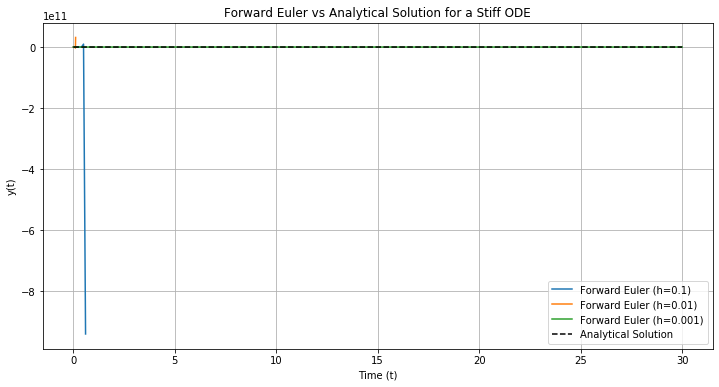

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -1000 * y + 3000 - 2000 * np.exp(-t)

def y_exact(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)

def forward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0

    for i in range(1, len(t_values)):
        y_values[i] = y_values[i - 1] + h * f(t_values[i - 1], y_values[i - 1])

        #I put a break here so the practical steps could still be plotted
        if abs(y_values[i]) > 1e10:
            print(f"Solution blew up for h = {h} at t = {t_values[i]}")
            t_values = t_values[:i+1]
            y_values = y_values[:i+1]
            break

    return t_values, y_values

y0 = 0
t0 = 0
tf = 30
h_values = [0.1, 0.01, 0.001, 0.00001, 0.0000001]

plt.figure(figsize=(12, 6))

for h in h_values:
    n_steps = int((tf - t0) / h)

    if n_steps > 1_000_000:
        print(f"h = {h} is computationally impractical ({n_steps:,} steps)")
        #step is skipped if it takes too long to compute
        continue

    t_values, y_values = forward_euler(f, y0, t0, tf, h)
    plt.plot(t_values, y_values, label=f'Forward Euler (h={h})')

t_exact = np.linspace(t0, tf, 2000)
y_values_exact = y_exact(t_exact)
plt.plot(t_exact, y_values_exact, 'k--', label='Analytical Solution')

plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title('Forward Euler vs Analytical Solution for a Stiff ODE')
plt.legend()
plt.grid(True)
plt.show()
